Dataset Shape: (4095, 6)

--- Session ID check ---
Unique Session IDs: [0 1]
Value counts for Session ID:
 session_id
0    4031
1      64
Name: count, dtype: int64

--- Time check ---
Total duration recorded: 160800.0 seconds (44.67 hours)
Estimated rows for 8 hours at 30s interval: 960.0

--- Replica Count distribution ---
replica_count
0.0     35
1.0    766
2.0    931
3.0    824
4.0    189
5.0    299
6.0    245
7.0    321
8.0    461
9.0     24
Name: count, dtype: int64


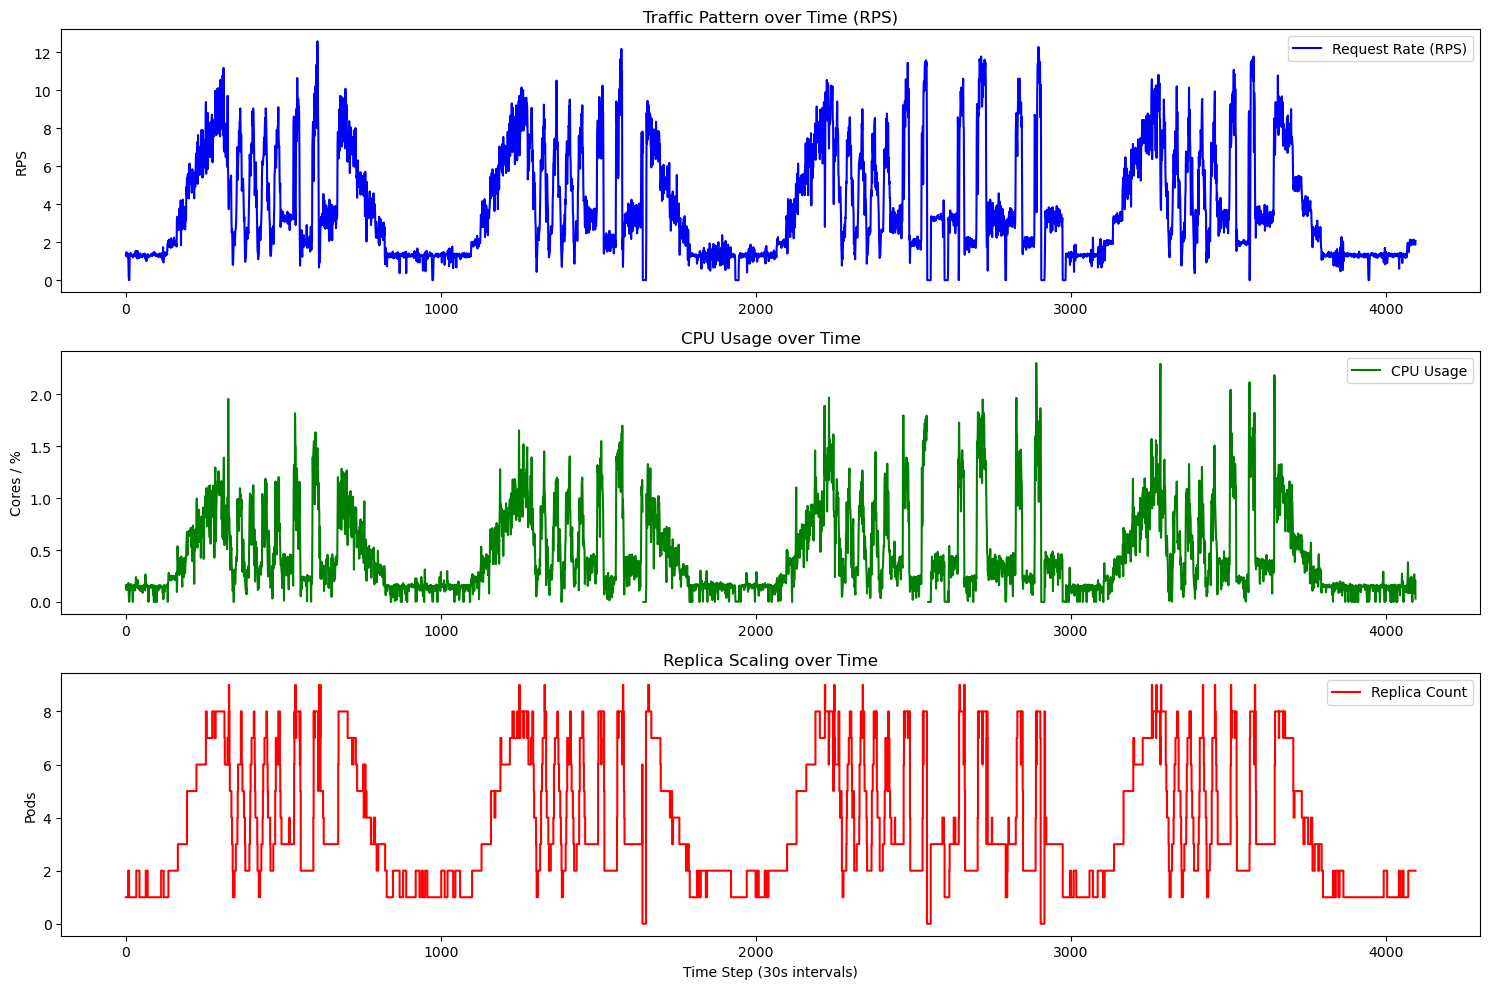

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('training_dataset.csv')

# Basic info
print("Dataset Shape:", df.shape)
print("\n--- Session ID check ---")
print("Unique Session IDs:", df['session_id'].unique())
print("Value counts for Session ID:\n", df['session_id'].value_counts())

# Time check
duration_seconds = df['timestamp'].max() - df['timestamp'].min()
print(f"\n--- Time check ---")
print(f"Total duration recorded: {duration_seconds} seconds ({duration_seconds / 3600:.2f} hours)")
print(f"Estimated rows for 8 hours at 30s interval: {28800 / 30}")

# Replicas check

print("\n--- Replica Count distribution ---")
print(df['replica_count'].value_counts().sort_index())

# Plot the patterns to see how they look
plt.figure(figsize=(15, 10))

# Plot 1: Request Rate
plt.subplot(3, 1, 1)
plt.plot(df.index, df['request_rate'], label='Request Rate (RPS)', color='blue')
plt.title('Traffic Pattern over Time (RPS)')
plt.ylabel('RPS')
plt.legend()

# Plot 2: CPU Usage
plt.subplot(3, 1, 2)
plt.plot(df.index, df['cpu_usage'], label='CPU Usage', color='green')
plt.title('CPU Usage over Time')
plt.ylabel('Cores / %')
plt.legend()

# Plot 3: Replicas
plt.subplot(3, 1, 3)
plt.plot(df.index, df['replica_count'], label='Replica Count', color='red', drawstyle='steps-post')
plt.title('Replica Scaling over Time')
plt.ylabel('Pods')
plt.xlabel('Time Step (30s intervals)')
plt.legend()


plt.tight_layout()
plt.savefig('new_dataset_patterns.png')
plt.show()